# Net-Hub 1-Pager 발표용 Notebook v2
## 글로벌 OTT의 콘텐츠 수급 및 현지화 전략 분석

> **발표 목적**  
> 1-Pager에 적힌 내용을 데이터와 그래프로 설명한다. 핵심 질문은 **“어떤 콘텐츠를 더 확보해야 하는가?”**이다.  
> 이를 위해 `Kaggle Netflix 카탈로그 데이터`를 **공급 데이터**, `Netflix Engagement Report`를 **수요/시청시간 데이터**로 사용한다.

---

## 15분 발표 흐름

| 구간 | 핵심 질문 | 발표 포인트 |
|---|---|---|
| 1 | 왜 이 분석이 필요한가? | 콘텐츠 수급 의사결정은 공급량만으로 판단하기 어렵고, 시청시간과 함께 봐야 함 |
| 2 | 어떤 데이터를 쓰는가? | Kaggle = 2021년까지의 카탈로그 / Engagement = 2023년 상반기 글로벌 시청시간 |
| 3 | 어떻게 두 데이터를 연결하는가? | `title_key` 정제 후 조인, 매칭률로 분석 가능성 확인 |
| 4 | EDA는 무엇을 확인하는가? | 제작국가·장르·유형을 가중치로 분해해 공급 구조 확인 |
| 5 | 핵심 지표는 무엇인가? | `Efficiency Index = Watch Share / Supply Share` |
| 6 | 민감도는 왜 보는가? | 상위 인기작 1개가 세그먼트 전체를 왜곡하는지 확인 |
| 7 | 모델링은 왜 하는가? | 고효율 세그먼트를 단순 규칙이 아닌 회귀 기반 랭킹으로 보조 검증 |
| 8 | 최종 결과는 무엇인가? | 전체 TOP5 + 대륙별 TOP5 + 한계점 |

# 1. 1-Pager 핵심 내용 요약

## WHY — 비즈니스 문제
- **한 줄 요약**: 어떤 콘텐츠를 더 확보해야 하는가?
- **접근 방향**: 공급 데이터와 수요 데이터를 결합해 **공급 대비 시청효율이 높은 국가 × 장르 × 유형 세그먼트**를 찾는다.
- **의사결정자 관점**: 콘텐츠 수급 담당자와 글로벌 전략팀이 “어느 국가·장르·유형의 콘텐츠를 우선 확보할지” 판단하는 데 활용한다.

## WHAT — 성공 지표
| 단계 | KPI | 의미 |
|---|---|---|
| 1차 | Kaggle ↔ Engagement `title_key` 매칭률 | 두 데이터가 분석 가능한 수준으로 붙는지 확인 |
| 2차 | `Efficiency Index = Watch Share / Supply Share` | 공급 대비 시청효율이 높은 세그먼트 도출 |
| 비즈니스 | 콘텐츠 확보 우선순위 Top5 | 향후 수급 후보를 국가·장르·유형 조합으로 제안 |

## HOW — 데이터 · ML 접근법
- `country`, `listed_in`은 복수값이 들어 있으므로 **explode + weight** 방식으로 분해한다.
- 먼저 규칙 기반 `Efficiency Index`로 랭킹을 만들고, 이후 회귀 기반 모델로 랭킹 신호를 보조 검증한다.
- 시청시간은 상위 인기작에 쏠리므로 `log1p(Hours Viewed)` 변환과 최소 표본 수 기준을 적용한다.

# 2. 데이터 로드 및 기본 구조 확인

## 확인 목적
본격적인 분석 전에 두 데이터가 실제로 1-Pager의 가정과 맞는지 확인한다.

- Kaggle 데이터가 실제로 콘텐츠 메타데이터인지 확인
- Engagement Report에 시청시간이 포함되어 있는지 확인
- 두 데이터의 단위와 시점이 다르다는 점을 명확히 인지

> 주의: Kaggle 데이터의 `country`는 **소비 국가가 아니라 제작국가 또는 제작 참여 국가**로 해석해야 한다.

In [1]:
# 기본 라이브러리 로드
# - pandas/numpy: 데이터 처리
# - matplotlib: 발표용 그래프 생성
# - pathlib: 파일 경로 탐색
# - re: 제목 정제(title_key 생성)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# 노트북을 다른 환경에서 실행해도 파일을 찾을 수 있도록 여러 경로를 탐색한다.
def find_file(filename):
    candidates = [Path(filename), Path('/mnt/data') / filename, Path.cwd() / filename]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"파일을 찾을 수 없습니다: {filename}")

netflix_path = find_file('netflix_titles.csv')
engagement_path = find_file('What_We_Watched_A_Netflix_Engagement_Report_2023Jan-Jun.xlsx')

# Kaggle Netflix catalog 데이터 로드
netflix = pd.read_csv(netflix_path)

# Engagement Report는 실제 컬럼명이 엑셀 6번째 행에 있으므로 header=5를 사용한다.
engagement = pd.read_excel(engagement_path, header=5)
engagement = engagement.dropna(subset=['Title']).copy()

print(f"Kaggle Netflix 데이터: {netflix.shape[0]:,}행 × {netflix.shape[1]:,}컬럼")
print(f"Engagement Report 데이터: {engagement.shape[0]:,}행 × {engagement.shape[1]:,}컬럼")

display(netflix.head(3))
display(engagement.head(3))

Kaggle Netflix 데이터: 8,807행 × 12컬럼
Engagement Report 데이터: 18,214행 × 5컬럼


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


,Unnamed: 0,Title,Available Globally?,Release Date,Hours Viewed
0,NaN,The Night Agent: Season 1,Yes,2023-03-23,812100000
1,NaN,Ginny & Georgia: Season 2,Yes,2023-01-05,665100000
2,NaN,The Glory: Season 1 // 더 글로리: 시즌 1,Yes,2022-12-30,622800000


In [2]:
# 데이터 품질을 빠르게 점검한다.
# 결측치가 높은 컬럼은 해석과 모델링에서 주의해야 한다.

missing_rate = (
    netflix.isna().mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .reset_index()
)
missing_rate.columns = ['column', 'missing_rate_pct']

print("[Kaggle 데이터 결측치 비율]")
display(missing_rate)

# Engagement Report에서 핵심 컬럼인 Hours Viewed가 제대로 숫자로 들어 있는지 확인한다.
print("[Engagement Report 핵심 컬럼]")
display(engagement[['Title', 'Release Date', 'Hours Viewed']].head())
print(f"Engagement Report 총 시청시간: {engagement['Hours Viewed'].sum():,.0f} hours")

[Kaggle 데이터 결측치 비율]


,column,missing_rate_pct
0,director,29.91
1,country,9.44
2,cast,9.37
3,date_added,0.11
4,rating,0.05
5,duration,0.03
6,show_id,0.00
7,type,0.00
8,title,0.00
9,release_year,0.00


[Engagement Report 핵심 컬럼]


,Title,Release Date,Hours Viewed
0,The Night Agent: Season 1,2023-03-23,812100000
1,Ginny & Georgia: Season 2,2023-01-05,665100000
2,The Glory: Season 1 // 더 글로리: 시즌 1,2022-12-30,622800000
3,Wednesday: Season 1,2022-11-23,507700000
4,Queen Charlotte: A Bridgerton Story,2023-05-04,503000000


Engagement Report 총 시청시간: 93,455,200,000 hours


## 해석
Kaggle 데이터는 `type`, `country`, `listed_in`, `rating`, `release_year`, `date_added`처럼 콘텐츠 공급 구조를 설명하는 컬럼을 제공한다. 반면 `Hours Viewed`처럼 실제 소비 성과를 보여주는 컬럼은 없다. 따라서 Kaggle 데이터만으로는 **공급 구조**를 보고, Engagement Report를 붙여야 **시청 성과**를 볼 수 있다.

결측치 관점에서는 `director`, `cast`, `country`에 결측이 상대적으로 많다. 다만 이번 프로젝트의 핵심은 감독·출연진 분석이 아니라 국가·장르·유형 기반 세그먼트 분석이므로, 결측이 있는 국가는 `Unknown`으로 보존하고 분석에서 명시적으로 다루는 것이 적절하다.

# 3. `title_key` 생성 및 Kaggle ↔ Engagement 조인

## 왜 title_key가 필요한가?
두 데이터 모두 콘텐츠 제목을 가지고 있지만, 표기 방식이 다르다.

예시:
- `The Glory: Season 1 // 더 글로리: 시즌 1`
- `The Glory`
- 대소문자, 특수문자, 괄호, Season/Part/Volume 표기 차이

따라서 원본 제목을 그대로 조인하면 같은 콘텐츠가 다른 제목으로 인식될 수 있다.  
이번 노트북에서는 두 가지 기준을 비교한다.

| 기준 | 설명 | 장점 | 한계 |
|---|---|---|---|
| Conservative key | 특수문자와 현지어 병기만 정리 | 과매칭 위험이 낮음 | 시즌 표기 차이로 매칭 누락 가능 |
| Relaxed key | season/part/volume 표기도 제거 | 시리즈 단위 매칭에 유리 | 서로 다른 시즌을 하나의 시리즈로 합산할 수 있음 |

분석 본문에서는 **시청시간 세그먼트 분석에 필요한 커버리지를 확보하기 위해 Relaxed key**를 사용하되, 매칭 방식 자체가 결과에 영향을 줄 수 있음을 리스크로 남긴다.

In [3]:
# 제목 정제 함수 1: 보수적 기준
# - // 이후 현지어 병기를 제거한다.
# - 특수문자와 중복 공백을 제거한다.
# - Season/Part/Volume은 유지하므로 서로 다른 시즌을 섞을 위험이 작다.
def conservative_title_key(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = re.sub(r"//.*$", " ", x)
    x = re.sub(r"[^a-z0-9가-힣\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

# 제목 정제 함수 2: 완화 기준
# - 보수적 기준에 더해 괄호, season/part/volume 번호를 제거한다.
# - Engagement Report가 시즌 단위로 나누어진 경우, Kaggle의 시리즈 제목과 더 잘 매칭된다.
def relaxed_title_key(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = re.sub(r"//.*$", " ", x)
    x = re.sub(r"\([^)]*\)", " ", x)
    x = re.sub(r"\b(season|part|volume)\s*\d+\b", " ", x)
    x = re.sub(r"[^a-z0-9가-힣\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

# 두 기준의 title_key 생성
netflix['conservative_key'] = netflix['title'].apply(conservative_title_key)
netflix['title_key'] = netflix['title'].apply(relaxed_title_key)
engagement['conservative_key'] = engagement['Title'].apply(conservative_title_key)
engagement['title_key'] = engagement['Title'].apply(relaxed_title_key)

# Engagement Report에는 같은 title_key가 여러 행으로 존재할 수 있으므로 title_key 단위로 시청시간을 합산한다.
engagement_conservative = (
    engagement.groupby('conservative_key', as_index=False)
    .agg(hours_viewed=('Hours Viewed', 'sum'), engagement_rows=('Title', 'count'))
)

engagement_relaxed = (
    engagement.groupby('title_key', as_index=False)
    .agg(hours_viewed=('Hours Viewed', 'sum'), engagement_rows=('Title', 'count'))
)

# 두 기준으로 각각 조인한다.
merged_conservative = netflix.merge(engagement_conservative, on='conservative_key', how='left')
merged = netflix.merge(engagement_relaxed, on='title_key', how='left')

# 매칭률과 시청시간 커버리지 계산
match_summary = pd.DataFrame({
    'matching_rule': ['Conservative key', 'Relaxed key'],
    'matched_kaggle_titles': [
        merged_conservative['hours_viewed'].notna().sum(),
        merged['hours_viewed'].notna().sum()
    ],
    'total_kaggle_titles': [len(netflix), len(netflix)],
    'covered_hours': [
        merged_conservative['hours_viewed'].sum(),
        merged['hours_viewed'].sum()
    ]
})
match_summary['match_ratio'] = match_summary['matched_kaggle_titles'] / match_summary['total_kaggle_titles']
match_summary['hours_coverage_ratio'] = match_summary['covered_hours'] / engagement['Hours Viewed'].sum()
match_summary['pass_1pager_kpi_25pct'] = match_summary['match_ratio'] >= 0.25

# 발표용으로 보기 좋게 포맷팅
match_summary_display = match_summary.copy()
match_summary_display['match_ratio'] = (match_summary_display['match_ratio'] * 100).round(1).astype(str) + '%'
match_summary_display['hours_coverage_ratio'] = (match_summary_display['hours_coverage_ratio'] * 100).round(1).astype(str) + '%'
match_summary_display['covered_hours'] = match_summary_display['covered_hours'].round(0).map('{:,.0f}'.format)

display(match_summary_display)

,matching_rule,matched_kaggle_titles,total_kaggle_titles,covered_hours,match_ratio,hours_coverage_ratio,pass_1pager_kpi_25pct
0,Conservative key,2939,8807,"6,388,200,000",33.4%,6.8%,True
1,Relaxed key,4760,8807,"44,319,500,000",54.0%,47.4%,True


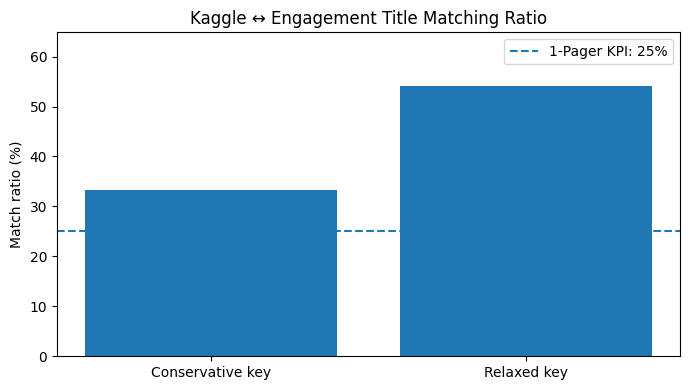

In [4]:
# 매칭률 시각화
# 1-Pager의 1차 KPI는 매칭률 25% 이상이므로, 기준선을 함께 표시한다.

plt.figure(figsize=(7, 4))
plt.bar(match_summary['matching_rule'], match_summary['match_ratio'] * 100)
plt.axhline(25, linestyle='--', label='1-Pager KPI: 25%')
plt.title('Kaggle ↔ Engagement Title Matching Ratio')
plt.ylabel('Match ratio (%)')
plt.ylim(0, max(60, match_summary['match_ratio'].max() * 120))
plt.legend()
plt.tight_layout()
plt.show()

## 해석
보수적 기준과 완화 기준 모두 1-Pager의 1차 KPI인 **매칭률 25%**를 넘는다. 완화 기준은 시리즈·시즌 표기 차이를 줄여 매칭률과 시청시간 커버리지를 크게 높인다. 따라서 이후 분석은 **완화 기준으로 조인한 데이터**를 사용한다.

다만 이 선택은 장점과 리스크가 함께 있다. 완화 기준은 시리즈 단위 성과를 보기 좋지만, 특정 시즌의 시청시간이 시리즈 전체로 합산될 수 있다. 그러므로 이후 결과는 “정밀한 타이틀별 매출 분석”이 아니라, **국가 × 장르 × 유형 세그먼트의 방향성을 보는 분석**으로 해석해야 한다.

# 4. 전처리: 다중 국가·장르를 `explode + weight` 방식으로 처리

## 왜 대표값이 아니라 가중치 방식인가?
`country`와 `listed_in`에는 여러 값이 들어갈 수 있다. 첫 번째 값만 대표값으로 사용하면 공동제작국가나 복합장르 정보가 사라진다. 반대로 모두 1개씩 세면 콘텐츠 하나가 여러 번 카운트된다.

그래서 이번 분석은 다음 방식으로 처리한다.

- 제작국가가 2개인 콘텐츠 → 각 제작국가에 0.5씩 부여
- 장르가 3개인 콘텐츠 → 각 장르에 1/3씩 부여
- 국가와 장르를 동시에 볼 때는 `country_weight × genre_weight`를 세그먼트 가중치로 사용

이 방식은 **정보 손실을 줄이면서도 과대 집계를 방지**하기 위한 전처리이다.

In [5]:
# 리스트 분해 함수
# 결측값은 Unknown으로 남겨서 표본을 버리지 않고, 결측 자체를 하나의 상태로 추적한다.
def split_list(x):
    if pd.isna(x) or str(x).strip() == '':
        return ['Unknown']
    return [item.strip() for item in str(x).split(',') if item.strip()]

# 날짜 파생 변수 생성
# release_year: 콘텐츠 공개/제작 시점에 가까운 정보
# year_added: Netflix 카탈로그 등록연도
merged['date_added'] = pd.to_datetime(merged['date_added'], errors='coerce')
merged['year_added'] = merged['date_added'].dt.year

# 국가·장르 리스트 생성
merged['country_list'] = merged['country'].apply(split_list)
merged['genre_list'] = merged['listed_in'].apply(split_list)

# 가중치 계산
merged['country_weight'] = 1 / merged['country_list'].apply(len)
merged['genre_weight'] = 1 / merged['genre_list'].apply(len)

# 연령 등급 그룹 생성
# 세부 rating은 클래스가 많기 때문에, 분석/모델링 해석을 위해 상위 그룹으로 단순화한다.
kids = ['TV-Y', 'TV-Y7', 'TV-G', 'G']
teens = ['PG', 'PG-13', 'TV-PG', 'TV-14']
adults = ['R', 'NC-17', 'TV-MA']
not_rated = ['NR', 'UR']

def map_rating_group(x):
    if x in kids:
        return 'Kids'
    elif x in teens:
        return 'Teens'
    elif x in adults:
        return 'Adults'
    elif x in not_rated:
        return 'Not Rated'
    else:
        return 'Unknown'

merged['rating_group'] = merged['rating'].apply(map_rating_group)

# 대륙 매핑
# country는 소비 국가가 아니라 제작 국가이므로 production_country 기준으로 대륙을 붙인다.
Europe = ['Albania','Austria','Belarus','Belgium','Bulgaria','Croatia','Cyprus','Czech Republic','Denmark','East Germany','Finland','France','Germany','Greece','Hungary','Iceland','Ireland','Italy','Latvia','Liechtenstein','Lithuania','Luxembourg','Malta','Montenegro','Netherlands','Norway','Poland','Portugal','Romania','Russia','Serbia','Slovakia','Slovenia','Soviet Union','Spain','Sweden','Switzerland','Turkey','Ukraine','United Kingdom','Vatican City','West Germany']
Asia = ['Afghanistan','Armenia','Azerbaijan','Bangladesh','Cambodia','China','Georgia','Hong Kong','India','Indonesia','Iran','Iraq','Israel','Japan','Jordan','Kazakhstan','Kuwait','Lebanon','Malaysia','Mongolia','Nepal','Pakistan','Palestine','Philippines','Qatar','Saudi Arabia','Singapore','South Korea','Sri Lanka','Syria','Taiwan','Thailand','United Arab Emirates','Vietnam']
Africa = ['Algeria','Angola','Botswana','Burkina Faso','Cameroon','Egypt','Ethiopia','Ghana','Kenya','Malawi','Mauritius','Morocco','Mozambique','Namibia','Nigeria','Senegal','Somalia','South Africa','Sudan','Uganda','Zimbabwe']
NorthAmerica = ['Bahamas','Bermuda','Canada','Cayman Islands','Cuba','Dominican Republic','Guatemala','Jamaica','Mexico','Nicaragua','Panama','Puerto Rico','United States']
SouthAmerica = ['Argentina','Brazil','Chile','Colombia','Ecuador','Paraguay','Peru','Uruguay','Venezuela']
Oceania = ['Australia','New Zealand','Samoa']

continent_map = {}
for arr, cont in [(Europe,'Europe'), (Asia,'Asia'), (Africa,'Africa'), (NorthAmerica,'North America'), (SouthAmerica,'South America'), (Oceania,'Oceania')]:
    for c in arr:
        continent_map[c] = cont
continent_map['Unknown'] = 'Unknown'

def map_continent(country):
    return continent_map.get(country, 'Other/Unmapped')

# 국가와 장르를 모두 explode하여 세그먼트 분석 테이블 생성
segment_base = (
    merged
    .explode('country_list')
    .explode('genre_list')
    .rename(columns={'country_list': 'production_country', 'genre_list': 'genre'})
    .copy()
)

# 국가×장르 세그먼트 가중치
segment_base['continent'] = segment_base['production_country'].apply(map_continent)
segment_base['segment_weight'] = segment_base['country_weight'] * segment_base['genre_weight']
segment_base['weighted_supply'] = segment_base['segment_weight']
segment_base['weighted_hours'] = segment_base['hours_viewed'].fillna(0) * segment_base['segment_weight']
segment_base['matched_flag'] = segment_base['hours_viewed'].notna().astype(int)

# 전처리 결과 확인
print(f"세그먼트 분석용 행 수: {len(segment_base):,}")
display(segment_base[['title','type','production_country','continent','genre','rating_group','country_weight','genre_weight','segment_weight','hours_viewed']].head(10))

세그먼트 분석용 행 수: 23,749


,title,type,production_country,continent,genre,rating_group,country_weight,genre_weight,segment_weight,hours_viewed
0,Dick Johnson Is Dead,Movie,United States,North America,Documentaries,Teens,1.0,1.000000,1.000000,NaN
1,Blood & Water,TV Show,South Africa,Africa,International TV Shows,Adults,1.0,0.333333,0.333333,27200000.0
1,Blood & Water,TV Show,South Africa,Africa,TV Dramas,Adults,1.0,0.333333,0.333333,27200000.0
1,Blood & Water,TV Show,South Africa,Africa,TV Mysteries,Adults,1.0,0.333333,0.333333,27200000.0
2,Ganglands,TV Show,Unknown,Unknown,Crime TV Shows,Adults,1.0,0.333333,0.333333,85300000.0
2,Ganglands,TV Show,Unknown,Unknown,International TV Shows,Adults,1.0,0.333333,0.333333,85300000.0
2,Ganglands,TV Show,Unknown,Unknown,TV Action & Adventure,Adults,1.0,0.333333,0.333333,85300000.0
3,Jailbirds New Orleans,TV Show,Unknown,Unknown,Docuseries,Adults,1.0,0.500000,0.500000,2000000.0
3,Jailbirds New Orleans,TV Show,Unknown,Unknown,Reality TV,Adults,1.0,0.500000,0.500000,2000000.0
4,Kota Factory,TV Show,India,Asia,International TV Shows,Adults,1.0,0.333333,0.333333,2400000.0


## 해석
이 전처리 이후 분석 단위는 원래의 “콘텐츠 1행”이 아니라 **제작국가 × 장르 × 유형으로 분해된 세그먼트 행**이 된다. 이 방식 덕분에 다중 제작국가와 복합장르를 가진 콘텐츠도 분석에 반영된다.

다만 가중치 분해는 “정확한 수익 배분”이 아니라 **공급/시청시간을 공정하게 나누기 위한 분석 가정**이다. 따라서 최종 결과도 절대적인 투자 결론이 아니라, 콘텐츠 확보 후보군을 좁히는 의사결정 보조 지표로 해석해야 한다.

# 5. EDA 1 — 제작국가별 공급 구조

## 확인 목적
먼저 Kaggle 카탈로그 기준으로 어떤 제작국가의 콘텐츠가 많이 공급되어 있고, Movie와 TV Show 비중이 어떻게 다른지 확인한다.

이 단계에서 보려는 것은 “어느 나라 사람들이 무엇을 봤는가”가 아니라, **어느 제작국가의 콘텐츠가 넷플릭스 카탈로그에 어떤 유형으로 많이 존재하는가**이다.

type,total_weighted,movie_pct,tvshow_pct
production_country,,,
United States,3187.9,73.7,26.3
India,1003.2,91.9,8.1
Unknown,831.0,52.9,47.1
United Kingdom,570.5,58.3,41.7
Canada,288.1,69.5,30.5
Japan,273.2,33.9,66.1
France,222.9,71.1,28.9
South Korea,211.8,23.0,77.0
Spain,178.9,70.6,29.4


<Figure size 1000x500 with 0 Axes>

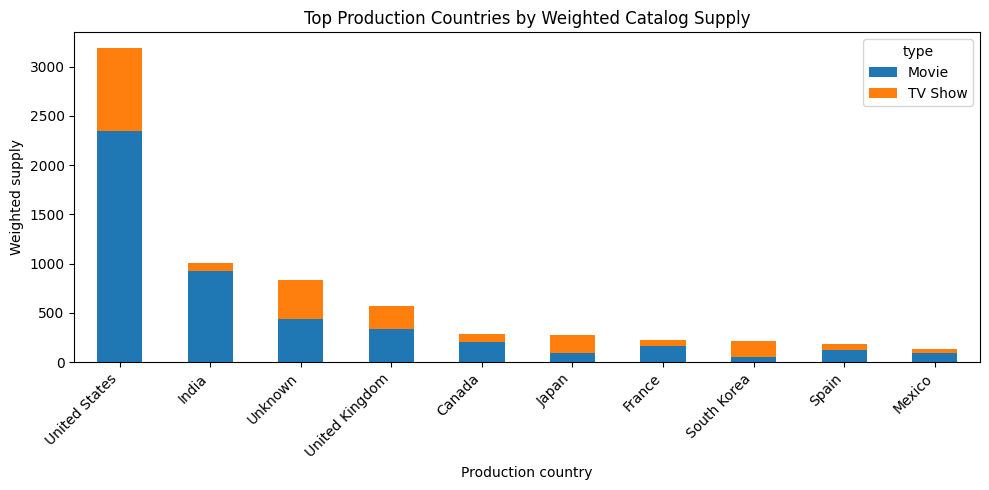

In [6]:
# 제작국가×유형별 가중 공급량 집계
country_type = (
    segment_base
    .drop_duplicates(subset=['show_id','production_country','type'])
    .groupby(['production_country','type'], as_index=False)
    .agg(weighted_titles=('country_weight','sum'))
)

country_type_pivot = (
    country_type
    .pivot(index='production_country', columns='type', values='weighted_titles')
    .fillna(0)
)
country_type_pivot['total_weighted'] = country_type_pivot.sum(axis=1)
country_type_pivot['movie_pct'] = country_type_pivot.get('Movie', 0) / country_type_pivot['total_weighted']
country_type_pivot['tvshow_pct'] = country_type_pivot.get('TV Show', 0) / country_type_pivot['total_weighted']

top_country_supply = country_type_pivot.sort_values('total_weighted', ascending=False).head(10)

display(
    top_country_supply[['total_weighted','movie_pct','tvshow_pct']]
    .assign(
        total_weighted=lambda d: d['total_weighted'].round(1),
        movie_pct=lambda d: (d['movie_pct']*100).round(1),
        tvshow_pct=lambda d: (d['tvshow_pct']*100).round(1)
    )
)

# 시각화: 상위 제작국가의 Movie/TV Show 공급 구조
plt.figure(figsize=(10, 5))
top_country_supply[['Movie','TV Show']].plot(kind='bar', stacked=True, figsize=(10,5))
plt.title('Top Production Countries by Weighted Catalog Supply')
plt.xlabel('Production country')
plt.ylabel('Weighted supply')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 해석 및 다음 확인
상위 제작국가를 보면 미국과 인도의 공급량이 크고, 국가별 유형 구성은 서로 다르게 나타난다. 특히 미국과 인도는 Movie 비중이 높고, 한국·일본은 TV Show 비중이 상대적으로 높게 나타나는 구조가 확인된다.

이 결과만으로는 “수요가 높은 콘텐츠”를 알 수 없다. 하지만 공급 구조가 국가별로 다르다는 점은 이후 Efficiency Index 분석에서 중요하다. 만약 TV Show 중심인 국가의 시청시간 비중이 공급비중보다 높다면, 해당 국가의 TV Show 세그먼트가 콘텐츠 확보 후보가 될 수 있기 때문이다.

# 6. EDA 2 — 장르별 공급 구조와 연도 추세

## 확인 목적
장르는 콘텐츠 수급 의사결정의 핵심 단위이다. 같은 제작국가라도 장르에 따라 시청효율이 다를 수 있기 때문이다.

이 단계에서는 다음을 확인한다.

1. 어떤 장르가 카탈로그에 많이 공급되어 있는가?
2. 주요 장르는 `year_added` 기준으로 어떻게 변화했는가?
3. 이후 국가×장르×유형 세그먼트 분석에서 어떤 장르를 주목해야 하는가?

,genre,weighted_supply
16,International Movies,1083.5
12,Dramas,1027.2
7,Comedies,732.7
10,Documentaries,594.2
17,International TV Shows,505.5
0,Action & Adventure,418.2
4,Children & Family Movies,404.5
30,Stand-Up Comedy,338.5
18,Kids' TV,326.7
34,TV Dramas,311.2


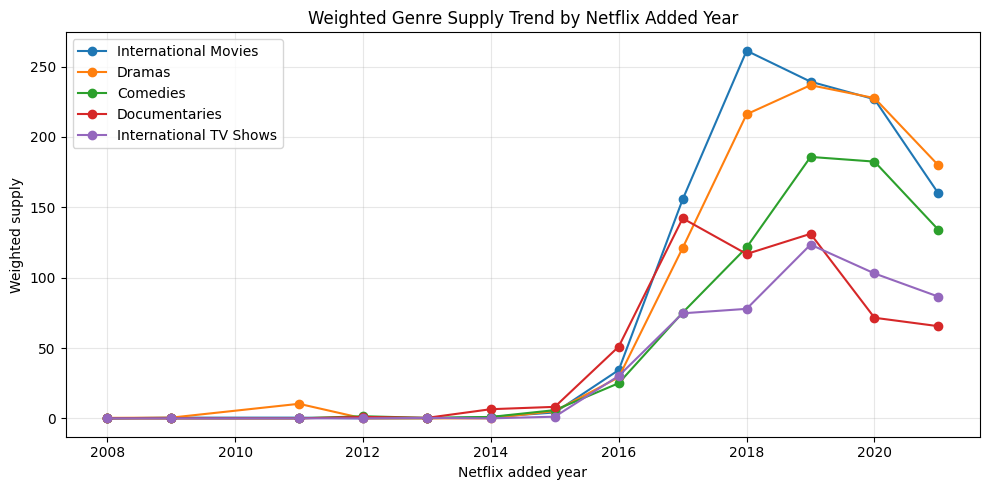

In [7]:
# 장르별 가중 공급량 집계
# segment_base는 이미 장르가 explode되어 있으므로 genre_weight를 활용한다.
genre_supply = (
    segment_base
    .drop_duplicates(subset=['show_id','genre'])
    .groupby('genre', as_index=False)
    .agg(weighted_supply=('genre_weight','sum'))
    .sort_values('weighted_supply', ascending=False)
)

display(genre_supply.head(10).assign(weighted_supply=lambda d: d['weighted_supply'].round(1)))

# 상위 5개 장르의 year_added 기준 추세
# year_added는 Netflix 카탈로그 등록연도이므로, '제작국가'와 구분해 '등록연도'로 해석한다.
top5_genres = genre_supply.head(5)['genre'].tolist()

genre_year = (
    segment_base[segment_base['genre'].isin(top5_genres)]
    .dropna(subset=['year_added'])
    .drop_duplicates(subset=['show_id','genre','year_added'])
    .groupby(['year_added','genre'], as_index=False)
    .agg(weighted_supply=('genre_weight','sum'))
)

genre_year_pivot = genre_year.pivot(index='year_added', columns='genre', values='weighted_supply').fillna(0)

plt.figure(figsize=(10, 5))
for genre in top5_genres:
    plt.plot(genre_year_pivot.index, genre_year_pivot[genre], marker='o', label=genre)
plt.title('Weighted Genre Supply Trend by Netflix Added Year')
plt.xlabel('Netflix added year')
plt.ylabel('Weighted supply')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 해석 및 다음 확인
상위 장르에는 International Movies, Dramas, Comedies, Documentaries, International TV Shows가 포함된다. 이는 넷플릭스 카탈로그가 국제 콘텐츠와 드라마/코미디 중심으로 두껍게 구성되어 있음을 보여준다.

하지만 공급량이 많다는 것은 반드시 시청효율이 높다는 뜻이 아니다. 공급량이 이미 큰 장르는 Watch Share도 높을 가능성이 있지만, EI는 공급 대비 시청 비중을 비교하기 때문에 **공급이 적어도 시청시간이 높은 장르 조합**을 찾는 데 유리하다. 따라서 다음 단계에서는 공급량과 시청시간을 함께 결합한 세그먼트 지표를 계산한다.

# 7. 핵심 지표 — Efficiency Index 계산

## 왜 Efficiency Index가 필요한가?
콘텐츠 수급 의사결정에서 단순 시청시간만 보면 미국 대형 콘텐츠나 글로벌 히트작에 결과가 몰릴 가능성이 크다. 반대로 단순 공급량만 보면 실제 수요를 알 수 없다.

그래서 이번 프로젝트는 다음 지표를 사용한다.

\[
\text{Efficiency Index} = \frac{\text{Watch Share}}{\text{Supply Share}}
\]

| 지표 | 의미 |
|---|---|
| Supply Share | 특정 국가×장르×유형 세그먼트가 전체 공급에서 차지하는 비중 |
| Watch Share | 해당 세그먼트가 전체 시청시간에서 차지하는 비중 |
| Efficiency Index | 공급 비중 대비 시청 비중이 얼마나 높은지 |

- EI > 1: 공급 대비 시청효율이 높음
- EI = 1: 공급과 시청이 유사한 수준
- EI < 1: 공급 대비 시청효율이 낮음
- EI ≥ 1.5: 1-Pager 기준 고효율 세그먼트 후보

In [8]:
# 세그먼트 단위 집계
# 분석 단위: 대륙 × 제작국가 × 장르 × 유형
segment_summary = (
    segment_base
    .groupby(['continent','production_country','genre','type'], as_index=False)
    .agg(
        catalog_titles=('show_id','nunique'),
        matched_titles=('matched_flag','sum'),
        supply_weight=('weighted_supply','sum'),
        watch_hours=('weighted_hours','sum'),
        max_weighted_hours=('weighted_hours','max'),
        mean_weighted_hours=('weighted_hours','mean'),
        median_weighted_hours=('weighted_hours','median')
    )
)

# Supply Share / Watch Share / Efficiency Index 계산
segment_summary['supply_share'] = segment_summary['supply_weight'] / segment_summary['supply_weight'].sum()
segment_summary['watch_share'] = segment_summary['watch_hours'] / segment_summary['watch_hours'].sum()
segment_summary['efficiency_index'] = segment_summary['watch_share'] / segment_summary['supply_share']

# 이상치 민감도: 세그먼트 내 가장 큰 타이틀 1개가 전체 시청시간에서 차지하는 비중
segment_summary['top_title_dependency'] = segment_summary['max_weighted_hours'] / segment_summary['watch_hours'].replace(0, np.nan)

# 신뢰 가능한 비교를 위해 최소 기준 적용
# - matched_titles >= 5: 시청시간이 붙은 타이틀이 너무 적은 세그먼트 제외
# - supply_weight >= 3: 카탈로그 공급 규모가 너무 작은 세그먼트 제외
# - watch_hours > 0: 시청시간이 없는 세그먼트 제외
segment_filtered = segment_summary[
    (segment_summary['matched_titles'] >= 5) &
    (segment_summary['supply_weight'] >= 3) &
    (segment_summary['watch_hours'] > 0)
].copy()

# 최종 랭킹 점수
# EI만 쓰면 소수 표본/단일 히트작 세그먼트가 과대평가될 수 있어,
# 표본 수와 top-title 의존도를 함께 반영한다.
segment_filtered['rank_score'] = (
    segment_filtered['efficiency_index']
    * np.log1p(segment_filtered['matched_titles'])
    * (1 - segment_filtered['top_title_dependency'].clip(upper=0.99))
)

print(f"전체 세그먼트 수: {len(segment_summary):,}")
print(f"최소 표본 기준 통과 세그먼트 수: {len(segment_filtered):,}")

overall_top10 = segment_filtered.sort_values('rank_score', ascending=False).head(10)

display(
    overall_top10[[
        'continent','production_country','genre','type','matched_titles','supply_weight',
        'watch_hours','efficiency_index','top_title_dependency','rank_score'
    ]].assign(
        supply_weight=lambda d: d['supply_weight'].round(2),
        watch_hours=lambda d: d['watch_hours'].round(0).map('{:,.0f}'.format),
        efficiency_index=lambda d: d['efficiency_index'].round(2),
        top_title_dependency=lambda d: (d['top_title_dependency']*100).round(1).astype(str)+'%',
        rank_score=lambda d: d['rank_score'].round(2)
    )
)

전체 세그먼트 수: 1,450
최소 표본 기준 통과 세그먼트 수: 316


,continent,production_country,genre,type,matched_titles,supply_weight,watch_hours,efficiency_index,top_title_dependency,rank_score
1219,North America,United States,Romantic TV Shows,TV Show,29,16.53,"2,182,908,333",26.25,14.8%,76.08
1228,North America,United States,TV Dramas,TV Show,148,100.55,"5,340,667,222",10.56,6.0%,49.63
1226,North America,United States,TV Action & Adventure,TV Show,74,30.38,"1,684,187,500",11.02,14.7%,40.60
1231,North America,United States,TV Sci-Fi & Fantasy,TV Show,44,20.19,"894,291,667",8.80,21.7%,26.23
1202,North America,United States,Crime TV Shows,TV Show,72,51.68,"1,787,258,333",6.87,14.3%,25.27
1233,North America,United States,TV Thrillers,TV Show,20,9.03,"567,783,333",12.50,35.0%,24.72
1227,North America,United States,TV Comedies,TV Show,183,142.90,"3,714,802,778",5.17,9.2%,24.47
1378,South America,Colombia,Spanish-Language TV Shows,TV Show,23,8.19,"317,516,667",7.70,17.9%,20.10
1230,North America,United States,TV Mysteries,TV Show,29,15.11,"637,800,000",8.39,30.4%,19.85
1374,South America,Colombia,International TV Shows,TV Show,23,8.53,"317,516,667",7.40,17.9%,19.31


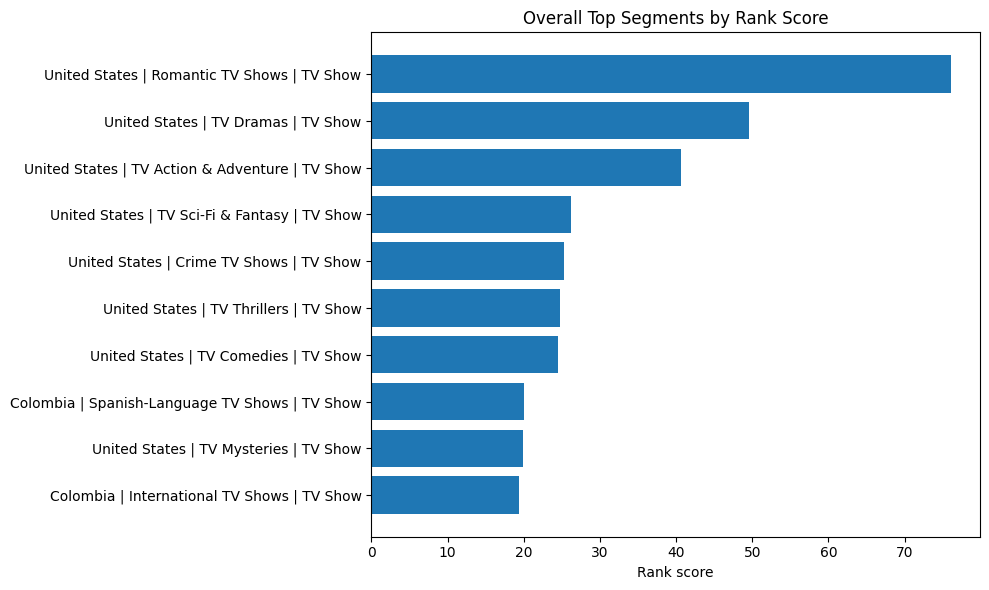

In [9]:
# 전체 Top10 시각화
# rank_score는 EI, 표본 수, 이상치 의존도를 함께 고려한 발표용 우선순위 점수이다.
plot_top = overall_top10.copy()
plot_top['segment'] = plot_top['production_country'] + ' | ' + plot_top['genre'] + ' | ' + plot_top['type']

plt.figure(figsize=(10, 6))
plt.barh(plot_top['segment'][::-1], plot_top['rank_score'][::-1])
plt.title('Overall Top Segments by Rank Score')
plt.xlabel('Rank score')
plt.tight_layout()
plt.show()

## 해석 및 다음 확인
전체 랭킹에서는 미국 TV Show 세그먼트가 강하게 나타난다. 특히 Romantic TV Shows, TV Dramas, TV Action & Adventure 등은 EI와 표본 수가 모두 높아 우선순위가 높게 나온다.

다만 이 결과만 사용하면 미국 중심의 결론으로 치우칠 가능성이 크다. 1-Pager의 목표는 글로벌 OTT의 콘텐츠 수급 및 현지화 전략 분석이므로, 전체 TOP5뿐 아니라 **대륙별 TOP5**를 함께 제시해야 한다. 그래야 미국 편중을 줄이고, 아시아·유럽·남미 등 지역별 전략 후보를 비교할 수 있다.

# 8. 민감도 분석 — 상위 히트작 1개가 결과를 왜곡하는가?

## 왜 민감도 분석이 필요한가?
시청시간 데이터는 소수의 초대형 인기작에 강하게 쏠릴 수 있다. 어떤 세그먼트의 EI가 높더라도, 사실상 타이틀 1개가 전체 시청시간을 대부분 차지한다면 해당 세그먼트를 안정적인 수급 후보로 보기 어렵다.

따라서 `top_title_dependency`를 계산한다.

\[
\text{Top Title Dependency} = \frac{\text{세그먼트 내 최대 타이틀 시청시간}}{\text{세그먼트 전체 시청시간}}
\]

- 값이 낮을수록 여러 타이틀이 고르게 성과를 낸 것
- 값이 높을수록 특정 1개 작품에 의존한 성과

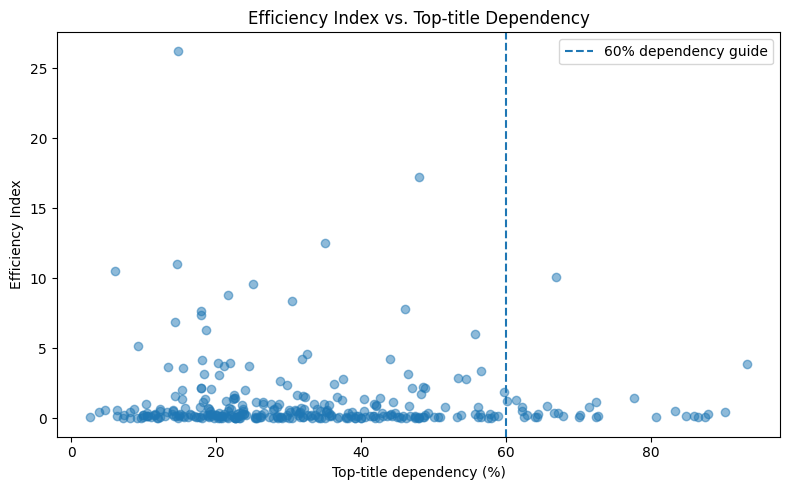

최소 표본 기준 통과 세그먼트: 316
top-title dependency <= 60% 세그먼트: 286


,continent,production_country,genre,type,matched_titles,efficiency_index,top_title_dependency,rank_score
1219,North America,United States,Romantic TV Shows,TV Show,29,26.25,14.8%,76.08
1228,North America,United States,TV Dramas,TV Show,148,10.56,6.0%,49.63
1226,North America,United States,TV Action & Adventure,TV Show,74,11.02,14.7%,40.60
1231,North America,United States,TV Sci-Fi & Fantasy,TV Show,44,8.80,21.7%,26.23
1202,North America,United States,Crime TV Shows,TV Show,72,6.87,14.3%,25.27
1233,North America,United States,TV Thrillers,TV Show,20,12.50,35.0%,24.72
1227,North America,United States,TV Comedies,TV Show,183,5.17,9.2%,24.47
1378,South America,Colombia,Spanish-Language TV Shows,TV Show,23,7.70,17.9%,20.10
1230,North America,United States,TV Mysteries,TV Show,29,8.39,30.4%,19.85
1374,South America,Colombia,International TV Shows,TV Show,23,7.40,17.9%,19.31


In [10]:
# EI와 top-title 의존도 관계 시각화
plt.figure(figsize=(8, 5))
plt.scatter(
    segment_filtered['top_title_dependency'] * 100,
    segment_filtered['efficiency_index'],
    alpha=0.5
)
plt.axvline(60, linestyle='--', label='60% dependency guide')
plt.title('Efficiency Index vs. Top-title Dependency')
plt.xlabel('Top-title dependency (%)')
plt.ylabel('Efficiency Index')
plt.legend()
plt.tight_layout()
plt.show()

# top-title 의존도가 60% 이하인 세그먼트와 전체 세그먼트 비교
stable_segments = segment_filtered[segment_filtered['top_title_dependency'] <= 0.60].copy()

print(f"최소 표본 기준 통과 세그먼트: {len(segment_filtered):,}")
print(f"top-title dependency <= 60% 세그먼트: {len(stable_segments):,}")

display(
    stable_segments.sort_values('rank_score', ascending=False).head(10)[[
        'continent','production_country','genre','type','matched_titles','efficiency_index','top_title_dependency','rank_score'
    ]].assign(
        efficiency_index=lambda d: d['efficiency_index'].round(2),
        top_title_dependency=lambda d: (d['top_title_dependency']*100).round(1).astype(str)+'%',
        rank_score=lambda d: d['rank_score'].round(2)
    )
)

## 해석
민감도 분석은 최종 우선순위에서 매우 중요하다. EI가 높더라도 top-title 의존도가 높으면 “해당 국가·장르·유형 세그먼트가 전반적으로 좋다”기보다 “특정 작품 하나가 크게 성공했다”는 의미일 수 있다.

따라서 최종 추천은 `EI`만으로 정하지 않고, `matched_titles`, `top_title_dependency`, `rank_score`를 함께 본다. 이 방식은 공급 대비 시청효율이 높으면서도, 일부 작품 하나에 지나치게 의존하지 않는 세그먼트를 찾기 위한 보수적인 기준이다.

# 9. 대륙별 TOP5 세그먼트

## 왜 대륙별 TOP5를 따로 보는가?
전체 순위는 미국 중심으로 쏠릴 가능성이 크다. 그러나 글로벌 OTT의 콘텐츠 수급 전략은 특정 국가 하나가 아니라 지역별 포트폴리오 전략으로 봐야 한다.

따라서 최종 발표에서는 전체 TOP5와 함께 **대륙별 TOP5**를 제시한다.  
이 방식은 다음 질문에 답한다.

- 아시아에서는 어떤 제작국가·장르·유형이 강한가?
- 유럽에서는 어떤 세그먼트가 공급 대비 시청효율이 좋은가?
- 남미/아프리카/오세아니아에서는 표본은 작지만 어떤 후보가 보이는가?

In [11]:
# 대륙별 TOP5 출력 함수
# rank_score 기준으로 대륙별 상위 5개 세그먼트를 출력한다.
def display_continent_top5(continent_name):
    sub = (
        segment_filtered[segment_filtered['continent'] == continent_name]
        .sort_values('rank_score', ascending=False)
        .head(5)
        .copy()
    )
    if len(sub) == 0:
        print(f"[{continent_name}] 조건을 만족하는 세그먼트가 없습니다.")
        return
    print(f"[{continent_name}] Top 5")
    display(
        sub[['production_country','genre','type','matched_titles','supply_weight','watch_hours','efficiency_index','top_title_dependency','rank_score']]
        .assign(
            supply_weight=lambda d: d['supply_weight'].round(2),
            watch_hours=lambda d: d['watch_hours'].round(0).map('{:,.0f}'.format),
            efficiency_index=lambda d: d['efficiency_index'].round(2),
            top_title_dependency=lambda d: (d['top_title_dependency']*100).round(1).astype(str)+'%',
            rank_score=lambda d: d['rank_score'].round(2)
        )
    )

for cont in ['Asia','Europe','North America','South America','Africa','Oceania']:
    display_continent_top5(cont)

[Asia] Top 5


,production_country,genre,type,matched_titles,supply_weight,watch_hours,efficiency_index,top_title_dependency,rank_score
464,South Korea,TV Comedies,TV Show,16,5.86,"298,600,000",10.12,66.9%,9.49
451,South Korea,International TV Shows,TV Show,100,51.50,"693,683,333",2.68,28.8%,8.80
459,South Korea,Romantic TV Shows,TV Show,49,25.28,"262,466,667",2.06,15.3%,6.84
453,South Korea,Korean TV Shows,TV Show,79,45.17,"551,266,667",2.43,36.2%,6.78
465,South Korea,TV Dramas,TV Show,27,13.44,"147,850,000",2.19,17.9%,5.98


[Europe] Top 5


,production_country,genre,type,matched_titles,supply_weight,watch_hours,efficiency_index,top_title_dependency,rank_score
1069,United Kingdom,Kids' TV,TV Show,35,17.51,"325,918,333",3.70,13.3%,11.49
987,Spain,Spanish-Language TV Shows,TV Show,30,12.83,"254,250,000",3.94,20.2%,10.79
977,Spain,International TV Shows,TV Show,39,16.31,"252,516,667",3.08,20.4%,9.04
969,Spain,Crime TV Shows,TV Show,19,7.50,"161,425,000",4.28,31.8%,8.73
1068,United Kingdom,International TV Shows,TV Show,77,40.12,"428,533,333",2.12,19.4%,7.46


[North America] Top 5


...

,production_country,genre,type,matched_titles,supply_weight,watch_hours,efficiency_index,top_title_dependency,rank_score
1378,Colombia,Spanish-Language TV Shows,TV Show,23,8.19,"317,516,667",7.70,17.9%,20.10
1374,Colombia,International TV Shows,TV Show,23,8.53,"317,516,667",7.40,17.9%,19.31
1368,Colombia,Crime TV Shows,TV Show,12,4.69,"226,122,222",9.57,25.1%,18.39
1346,Brazil,TV Dramas,TV Show,10,3.67,"40,533,333",2.20,48.8%,2.70
1334,Brazil,International TV Shows,TV Show,22,9.58,"46,983,333",0.97,42.1%,1.77


[Africa] Top 5


,production_country,genre,type,matched_titles,supply_weight,watch_hours,efficiency_index,top_title_dependency,rank_score
89,South Africa,Action & Adventure,Movie,8,3.04,"7,054,167",0.46,38.7%,0.62
100,South Africa,International Movies,Movie,19,10.75,"8,507,500",0.16,39.6%,0.28
69,Nigeria,Dramas,Movie,39,23.61,"16,733,333",0.14,58.4%,0.22
18,Egypt,Dramas,Movie,15,15.61,"8,022,222",0.10,40.5%,0.17
73,Nigeria,International Movies,Movie,54,33.69,"8,191,667",0.05,25.6%,0.14


[Oceania] Top 5


,production_country,genre,type,matched_titles,supply_weight,watch_hours,efficiency_index,top_title_dependency,rank_score
1252,Australia,Kids' TV,TV Show,17,9.46,"114,175,000",2.40,29.8%,4.87
1265,Australia,TV Dramas,TV Show,13,6.48,"90,820,000",2.79,37.4%,4.60
1264,Australia,TV Comedies,TV Show,12,8.12,"59,333,333",1.45,42.6%,2.13
1251,Australia,International TV Shows,TV Show,20,11.08,"44,200,000",0.79,28.4%,1.73
1239,Australia,Children & Family Movies,Movie,15,6.92,"19,583,333",0.56,34.3%,1.02


## 해석
대륙별 TOP5를 보면 전체 순위에서 가려졌던 지역별 후보가 드러난다.

- **North America**: 미국 TV Show 세그먼트가 강하게 나타나며, 특히 TV Dramas, Romantic TV Shows, TV Action & Adventure가 주요 후보이다.
- **Asia**: 한국 TV Show 세그먼트가 두드러진다. International TV Shows, Korean TV Shows, Romantic TV Shows는 공급 대비 시청효율과 표본 수를 함께 볼 때 후보로 남는다.
- **Europe**: 영국 Kids' TV, 스페인 Spanish-Language TV Shows / International TV Shows가 후보로 나타난다.
- **South America**: 콜롬비아 TV Show 관련 세그먼트가 상대적으로 강하게 나타난다.
- **Africa**: EI 자체는 낮게 나타나는 편이며, 이는 시청시간 매칭 표본과 글로벌 시청시간 커버리지의 한계가 반영된 것으로 해석해야 한다.
- **Oceania**: 호주 TV Show 세그먼트 일부가 후보로 나타나지만, 표본 수와 시청시간 규모를 함께 확인해야 한다.

즉, 최종 제안은 “미국 중심 전체 TOP5”만 제시하기보다, **대륙별 후보군을 함께 제시하고 각 대륙의 데이터 신뢰도와 표본 수를 함께 설명하는 방식**이 더 적절하다.

# 10. 모델 비교 — 규칙 기반 랭킹을 회귀 모델로 보조 검증

## 왜 모델링을 하는가?
Efficiency Index는 설명이 쉽고 비즈니스적으로 직관적이다. 하지만 EI는 규칙 기반 지표이므로, 세그먼트의 여러 속성을 동시에 고려하는 데 한계가 있다.

따라서 회귀 모델을 사용해 세그먼트의 `log1p(watch_hours)`를 예측하고, 모델이 실제 고시청 세그먼트의 순위를 어느 정도 재현하는지 확인한다.

## 모델 비교 기준
| 지표 | 의미 | 왜 사용하는가? |
|---|---|---|
| RMSE_log | 로그 시청시간 예측 오차 | 대략적인 예측 정확도 확인 |
| MAE_log | 평균 절대오차 | 이상치에 덜 민감한 오차 확인 |
| Spearman rank corr | 실제 순위와 예측 순위의 상관 | 우선순위 랭킹 목적에 적합 |
| Top 20% overlap | 실제 상위 20%와 예측 상위 20%의 겹침 | 고효율 후보 탐색 성능 확인 |

이번 프로젝트의 목적은 정확한 시청시간 예측보다 **우선순위 랭킹**이므로, Spearman 순위상관과 Top 20% overlap을 중요하게 본다.

In [12]:
# 모델링용 데이터 구성
# 목표: 국가×장르×유형 세그먼트의 log 시청시간을 예측해 랭킹 보조 지표로 활용
model_df = segment_filtered.copy()
model_df['target_log_watch_hours'] = np.log1p(model_df['watch_hours'])

# 피처 구성
# 범주형: 대륙, 제작국가, 장르, 유형
# 수치형: 공급량, 매칭 타이틀 수, 공급비중, top-title 의존도
feature_cols = [
    'continent', 'production_country', 'genre', 'type',
    'supply_weight', 'matched_titles', 'supply_share', 'top_title_dependency'
]

X = model_df[feature_cols]
y = model_df['target_log_watch_hours']

print(f"모델링용 세그먼트 수: {len(model_df):,}")
display(model_df[feature_cols + ['watch_hours','target_log_watch_hours','efficiency_index','rank_score']].head())

모델링용 세그먼트 수: 316


,continent,production_country,genre,type,supply_weight,matched_titles,supply_share,top_title_dependency,watch_hours,target_log_watch_hours,efficiency_index,rank_score
15,Africa,Egypt,Comedies,Movie,23.833333,10,0.002706,0.304094,2.850000e+06,14.862830,0.023763,0.039653
18,Africa,Egypt,Dramas,Movie,15.611111,15,0.001773,0.405125,8.022222e+06,15.897726,0.102116,0.168425
21,Africa,Egypt,International Movies,Movie,39.222222,21,0.004454,0.382103,8.505556e+06,15.956230,0.043093,0.082305
22,Africa,Egypt,International TV Shows,TV Show,5.433333,5,0.000617,0.391705,1.446667e+06,14.184773,0.052910,0.057667
28,Africa,Egypt,TV Dramas,TV Show,4.266667,5,0.000484,0.391705,1.446667e+06,14.184773,0.067377,0.073436


In [13]:
# 회귀 모델 비교
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

try:
    from lightgbm import LGBMRegressor
    use_lightgbm = True
except Exception:
    from sklearn.ensemble import HistGradientBoostingRegressor
    use_lightgbm = False

categorical_features = ['continent', 'production_country', 'genre', 'type']
numeric_features = ['supply_weight', 'matched_titles', 'supply_share', 'top_title_dependency']

# 데이터가 크지 않으므로 간단한 holdout 검증을 사용한다.
# 프로젝트 목적이 최종 운영 모델이 아니라 발표용 랭킹 실험이므로, 여기서는 비교 기준을 단순하게 둔다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001, max_iter=5000)
}

if use_lightgbm:
    models['LightGBM'] = LGBMRegressor(
        n_estimators=50,
        learning_rate=0.05,
        num_leaves=15,
        min_child_samples=5,
        random_state=42,
        verbose=-1,
        n_jobs=1
    )
else:
    models['HistGradientBoosting'] = HistGradientBoostingRegressor(
        max_iter=80,
        learning_rate=0.05,
        random_state=42
    )

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    rmse = mean_squared_error(y_test, pred) ** 0.5
    mae = mean_absolute_error(y_test, pred)
    rank_corr = spearmanr(y_test, pred).correlation

    # 실제 상위 20%와 예측 상위 20%가 얼마나 겹치는지 확인한다.
    eval_df = X_test.copy()
    eval_df['actual'] = y_test.values
    eval_df['pred'] = pred
    top_n = max(1, int(len(eval_df) * 0.2))
    actual_top = set(eval_df.sort_values('actual', ascending=False).head(top_n).index)
    pred_top = set(eval_df.sort_values('pred', ascending=False).head(top_n).index)
    top20_overlap = len(actual_top & pred_top) / top_n

    results.append({
        'model': name,
        'RMSE_log': rmse,
        'MAE_log': mae,
        'Spearman_rank_corr': rank_corr,
        'Top20pct_overlap': top20_overlap
    })

model_results = pd.DataFrame(results).sort_values('Spearman_rank_corr', ascending=False)
display(model_results.round(3))

/opt/pyvenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,RMSE_log,MAE_log,Spearman_rank_corr,Top20pct_overlap
2,LightGBM,0.952,0.689,0.834,0.800
0,Ridge,1.044,0.787,0.808,0.733
1,Lasso,1.118,0.844,0.790,0.667


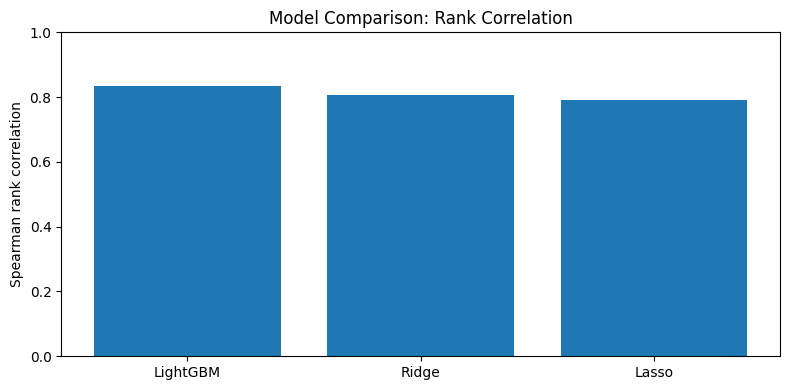

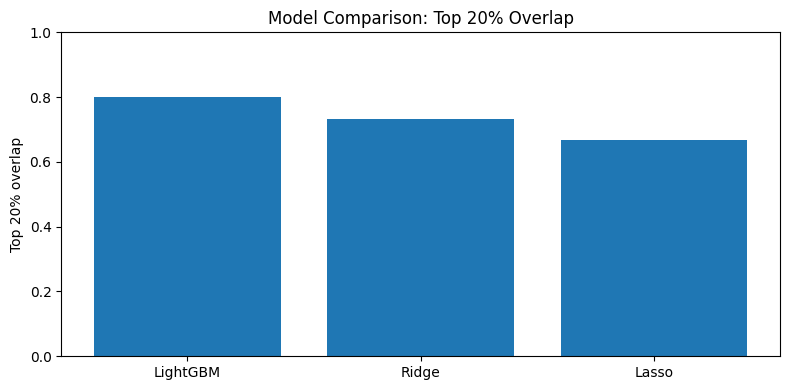

In [14]:
# 모델 비교 결과 시각화
plt.figure(figsize=(8, 4))
plt.bar(model_results['model'], model_results['Spearman_rank_corr'])
plt.title('Model Comparison: Rank Correlation')
plt.ylabel('Spearman rank correlation')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(model_results['model'], model_results['Top20pct_overlap'])
plt.title('Model Comparison: Top 20% Overlap')
plt.ylabel('Top 20% overlap')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 모델 결과 해석
모델 비교의 목적은 “정확한 시청시간 예측” 자체가 아니라, **고효율 세그먼트의 순위를 어느 정도 재현할 수 있는지**를 보는 것이다.

실행 결과에서 LightGBM 계열 모델이 Spearman 순위상관과 Top 20% overlap에서 가장 높은 성능을 보인다면, 국가·장르·유형 간 비선형 조합을 어느 정도 포착한다고 해석할 수 있다. 반대로 Ridge/Lasso는 성능이 조금 낮더라도 해석이 쉽기 때문에 기준선 모델로 의미가 있다.

최종 발표에서는 다음처럼 설명하는 것이 적절하다.

> “EI는 설명 가능한 규칙 기반 지표이고, 회귀 모델은 그 우선순위가 데이터 피처 조합에서도 재현되는지 검증하는 보조 장치로 사용했습니다. 최종 의사결정은 모델 하나의 점수가 아니라 EI, 표본 수, 이상치 민감도, 모델 랭킹을 함께 고려합니다.”

# 11. 최종 분석의 한계점

## 1. 데이터 시점 불일치
Kaggle 데이터는 2021년까지의 카탈로그 스냅샷이고, Engagement Report는 2023년 1~6월 글로벌 시청시간이다. 따라서 두 데이터가 완전히 같은 시점의 공급·수요를 의미하지 않는다.

## 2. 소비국가 데이터 부재
`country`는 소비국가가 아니라 제작국가이다. 따라서 “한국 사람들이 한국 콘텐츠를 많이 봤다”가 아니라, **한국에서 제작된 특정 장르/유형 콘텐츠가 글로벌 시청시간에서 높은 효율을 보였다**고 표현해야 한다.

## 3. title_key 조인 한계
완화된 `title_key` 기준은 시즌/파트 표기 차이를 줄여 매칭률을 높이지만, 일부 과매칭 가능성이 있다. 따라서 매칭률과 커버리지 개선의 장점과 과매칭 리스크를 함께 설명해야 한다.

## 4. 상위 히트작 편향
시청시간은 초대형 히트작에 집중될 수 있다. 그래서 `log1p` 변환, 최소 표본 수 기준, top-title dependency를 함께 사용했다.

## 5. EI는 의사결정 보조 지표
Efficiency Index는 공급 대비 시청효율을 보여주는 유용한 지표지만, 콘텐츠 제작비·라이선스 비용·마케팅 비용·지역별 구독자 반응까지 반영하지는 않는다. 따라서 최종 결론은 **투자 확정이 아니라 수급 후보군 추천**으로 해석해야 한다.

# 12. 15분 발표 마무리 문장

> 이번 프로젝트는 넷플릭스 카탈로그 데이터와 Engagement Report를 결합해, 공급 대비 시청효율이 높은 국가×장르×유형 세그먼트를 찾는 분석입니다.  
>  
> 핵심은 단순히 시청시간이 높은 콘텐츠를 찾는 것이 아니라, `Watch Share / Supply Share`를 통해 공급 대비 효율이 높은 세그먼트를 찾는 것입니다.  
>  
> 다만 전체 순위가 미국 중심으로 쏠릴 수 있기 때문에, 대륙별 TOP5를 함께 제시해 글로벌 콘텐츠 수급 전략 관점에서 후보군을 넓혔습니다.  
>  
> 최종적으로는 EI, 세그먼트별 표본 수, top-title dependency, 모델 랭킹 결과를 함께 고려하여 콘텐츠 확보 우선순위를 제안하는 방식으로 진행합니다.